In [1]:
import pandas as pd
import numpy as np

# 1. Setup Timeframe (208 weeks)
dates = pd.date_range(start="2015-11-23", periods=208, freq='W-MON')

# 2. Define Media Spending with Pulsed and Continuous Patterns
np.random.seed(42) # For reproducibility
def get_pulsed_spend(mean_val, max_val, probability=0.3):
    # Create pulses (0 or non-zero)
    pulses = np.random.choice([0, 1], size=208, p=[1-probability, probability])
    spend = pulses * np.random.uniform(low=mean_val*0.5, high=max_val, size=208)
    # Scale to match exact mean from Screenshot 192249
    return spend * (mean_val / spend.mean())

# Media Spend Columns
tv_s = get_pulsed_spend(111328, 1185349, probability=0.25)
ooh_s = get_pulsed_spend(81034, 938178, probability=0.20)
print_s = get_pulsed_spend(27965, 239417, probability=0.15)
facebook_s = get_pulsed_spend(64370, 462012, probability=0.60) # More frequent

# Search Spend: Trend + Seasonality
search_s_base = np.linspace(30000, 50000, 208) # Upward trend
search_s_seasonal = 5000 * np.sin(np.arange(208) * (2 * np.pi / 52))
search_s = search_s_base + search_s_seasonal + np.random.normal(0, 2000, 208)
search_s = np.clip(search_s, 0, 134100)
search_s = search_s * (44366 / search_s.mean()) # Match mean

# 3. Target Variable (Revenue)
# Base + Seasonality + Trend + Media Impact + Noise
time_index = np.arange(208)
revenue_base = 2500000
revenue_seasonal = 500000 * np.sin((time_index - 10) * (2 * np.pi / 52))
revenue_trend = np.linspace(0, 200000, 208)
media_impact = (tv_s * 0.5) + (facebook_s * 1.2) + (search_s * 2.0)

revenue = revenue_base + revenue_seasonal + revenue_trend + media_impact + np.random.normal(0, 100000, 208)

# 4. Create DataFrame
df = pd.DataFrame({
    'DATE': dates,
    'revenue': revenue,
    'tv_s': tv_s,
    'ooh_s': ooh_s,
    'print_s': print_s,
    'facebook_i': facebook_s * 1000, # Impressions approx 1000x spend
    'facebook_s': facebook_s,
    'search_clicks_p': search_s * 3, # Performance approx 3x spend
    'search_s': search_s,
    'competitor_sales_b': 8000000 + np.random.normal(0, 200000, 208)
})

In [2]:
import pytimetk as tk
# Old: from pymc_marketing.mmm.delayed_saturated_mmm import DelayedSaturatedMMM
from pymc_marketing.mmm import MMM
import arviz as az
import seaborn as sns
import matplotlib.pyplot as plt

c:\Users\mmopa\miniconda3\envs\mmm_study\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-02-17 09:16:47,797	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.


In [3]:
# DATA DEFINITION ----
df.glimpse()

<class 'pandas.DataFrame'>: 208 rows of 10 columns
DATE:                datetime64[us]    [Timestamp('2015-11-23 00:00:00') ...
revenue:             float64           [2188252.8546774313, 2379200.9280 ...
tv_s:                float64           [0.0, 171772.70374691798, 0.0, 0. ...
ooh_s:               float64           [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0. ...
print_s:             float64           [0.0, 0.0, 0.0, 0.0, 310533.19071 ...
facebook_i:          float64           [142548873.31317836, 140122098.47 ...
facebook_s:          float64           [142548.87331317837, 140122.09847 ...
search_clicks_p:     float64           [99783.32457983278, 100900.999563 ...
search_s:            float64           [33261.10819327759, 33633.6665211 ...
competitor_sales_b:  float64           [8221416.133857395, 7975923.76720 ...


In [4]:
# Data Definition:
# - revenue = sales, target variable
# - ooh_S = Out of Home (Billboards, etc.) Spend
# - tv_S = Television, Spend
# - print_S = Print Media (Newspapers, Magazines), Spend
# - facebook_I = Facebook Ads, Impressions
# - facebook_S = Facebook Ads, Spend
# - search_S = Google Search Ads, Search Spend
# - search_clicks_P = Google Search Ads Performance, (Number of Clicks)
# - competitor_sales_B = Competitor Sales Baseline

# * 1.0 EXPLORATORY DATA ANALYSIS ----
df.columns = [col.lower() for col in df.columns]

df.columns.tolist()


['date',
 'revenue',
 'tv_s',
 'ooh_s',
 'print_s',
 'facebook_i',
 'facebook_s',
 'search_clicks_p',
 'search_s',
 'competitor_sales_b']

In [5]:
df.head()

,date,revenue,tv_s,ooh_s,print_s,facebook_i,facebook_s,search_clicks_p,search_s,competitor_sales_b
0,2015-11-23,2.188253e+06,0.000000,0.0,0.000000,1.425489e+08,142548.873313,99783.324580,33261.108193,8.221416e+06
1,2015-11-30,2.379201e+06,171772.703747,0.0,0.000000,1.401221e+08,140122.098472,100900.999563,33633.666521,7.975924e+06
2,2015-12-07,2.211722e+06,0.000000,0.0,0.000000,5.418348e+07,54183.480081,109920.256936,36640.085645,7.565466e+06
3,2015-12-14,2.316953e+06,0.000000,0.0,0.000000,1.368348e+08,136834.787226,104145.575450,34715.191817,8.169484e+06
4,2015-12-21,2.315260e+06,0.000000,0.0,310533.190715,0.000000e+00,0.000000,109976.182794,36658.727598,7.892934e+06


In [6]:
import plotly.io as pio
pio.renderers.default = "png" # Or "browser" to open in a new tab

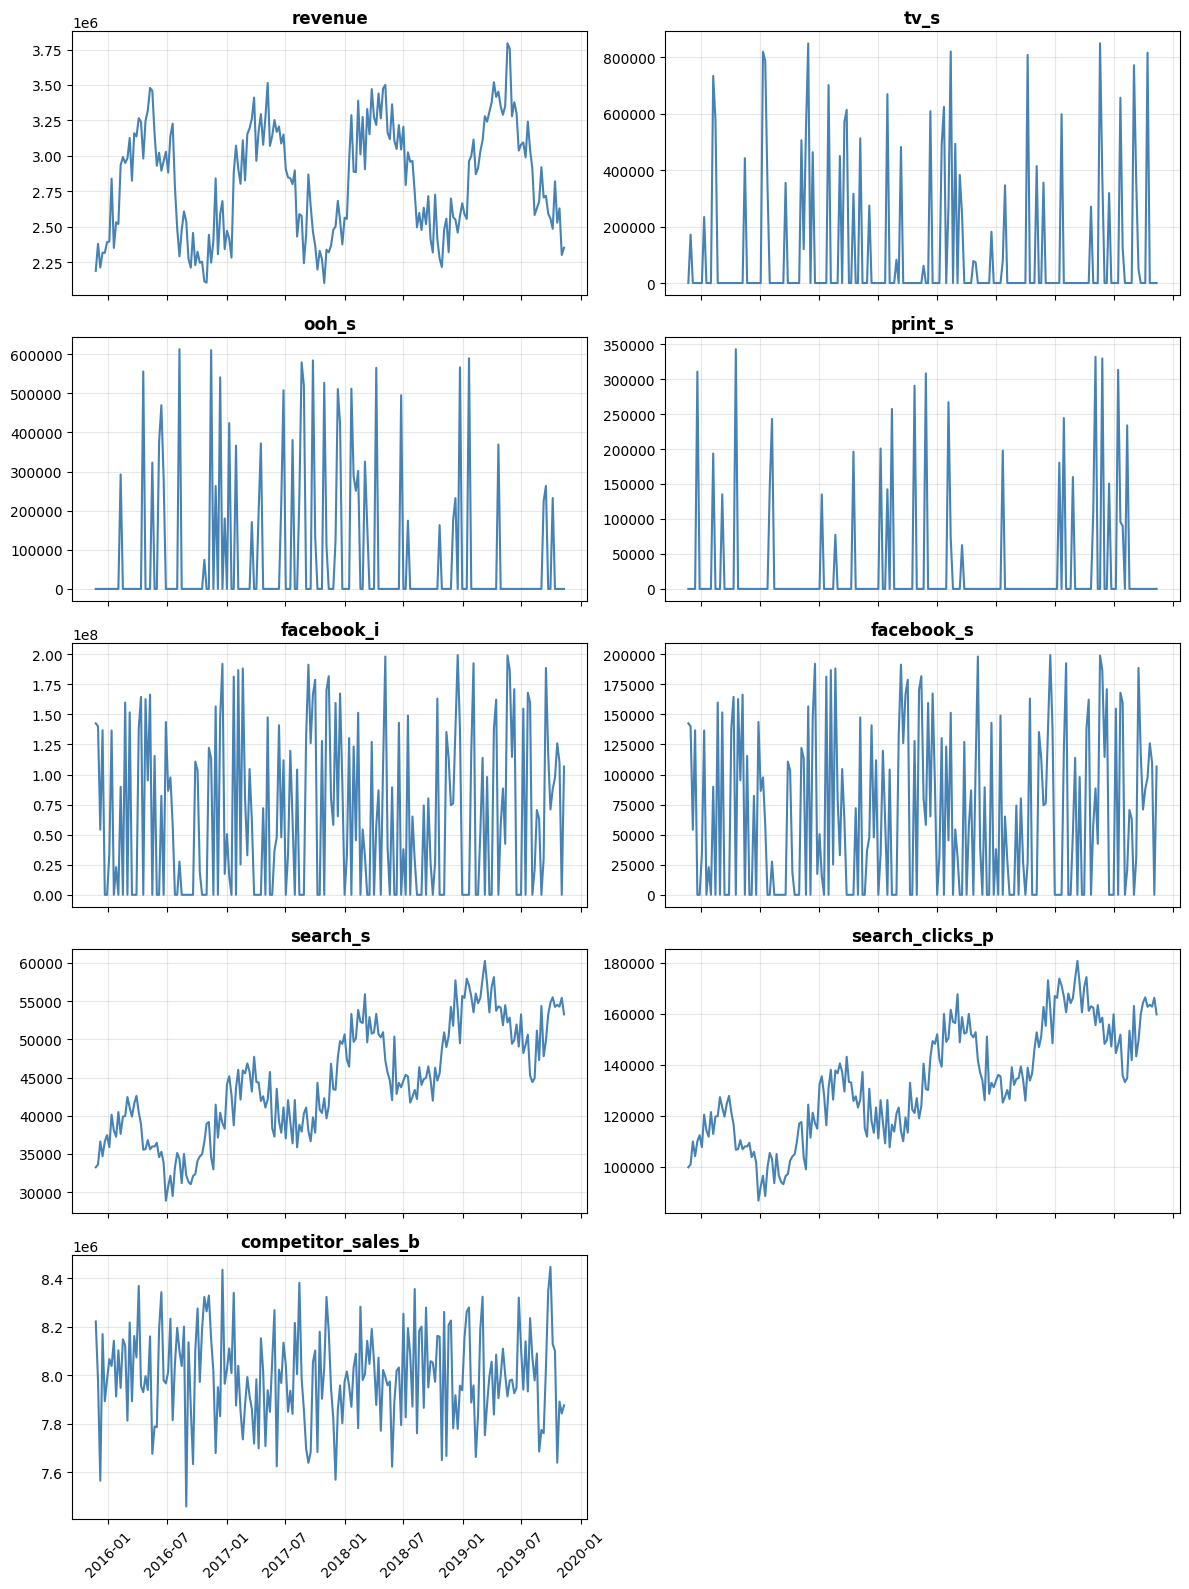

In [7]:
import matplotlib.pyplot as plt

# 1. Define the columns to plot (from your data)
cols_to_plot = ['revenue', 'tv_s', 'ooh_s', 'print_s', 
                'facebook_i', 'facebook_s', 'search_s', 
                'search_clicks_p', 'competitor_sales_b']

# 2. Create the grid (facet_ncol=2 logic)
n_cols = 2
n_rows = (len(cols_to_plot) + 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 16), sharex=True)
axes = axes.flatten()

# 3. Loop through columns and plot
for i, col in enumerate(cols_to_plot):
    axes[i].plot(df['date'], df[col], color='steelblue', lw=1.5)
    axes[i].set_title(col, fontsize=12, fontweight='bold')
    axes[i].grid(True, alpha=0.3)
    axes[i].tick_params(axis='x', rotation=45)

# Remove empty subplot if odd number of columns
if len(cols_to_plot) < len(axes):
    fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

In [8]:
# * Total Spend and Revenue Analysis
total_spend = df[['tv_s', 'ooh_s', 'print_s', 'facebook_s', 
'search_s']].sum(axis=0).sum()

total_revenue = df['revenue'].sum()

print(f'ROI: {(total_revenue / total_spend).round(2)} X')

ROI: 8.59 X


In [9]:
df['date']

0     2015-11-23
1     2015-11-30
2     2015-12-07
3     2015-12-14
4     2015-12-21
         ...    
203   2019-10-14
204   2019-10-21
205   2019-10-28
206   2019-11-04
207   2019-11-11
Name: date, Length: 208, dtype: datetime64[us]

In [10]:
df[['tv_s', 'ooh_s', 'print_s', 'facebook_s', 
'search_s']] \
    .describe() \
    .apply(lambda x: x.apply(lambda y: "{:,.0f}".format(y)))

,tv_s,ooh_s,print_s,facebook_s,search_s
count,208,208,208,208,208
mean,"111,328","81,034","27,965","64,370","44,366"
std,"227,480","166,972","76,663","65,976","7,327"
min,0,0,0,0,"28,895"
25%,0,0,0,0,"38,652"
50%,0,0,0,"47,772","44,208"
75%,"12,287",0,0,"122,456","50,438"
max,"850,171","612,650","342,669","199,354","60,243"


In [11]:
# * Monthly Ad Spend Analysis
median_spend = df[['tv_s', 'ooh_s', 'print_s', 
'facebook_s', 'search_s']].median()

mean_spend = df[['tv_s', 'ooh_s', 'print_s', 
'facebook_s', 'search_s']].mean()
mean_spend

df[['tv_s', 'ooh_s', 'print_s', 'facebook_s', 
'search_s']] \
    .describe() \
    .apply(lambda x: x.apply(lambda y: "{:,.0f}".format(y)))

mean_spend.sum()

np.float64(329063.0)

In [12]:
# QUESTION - IS THIS THE MOST PROFITABLE BASED ON THE CONTRIBUTION OF EACH CHANNEL?
# - LET'S TACKLE THIS QUESTION BY BUILDING A MARKETING MIX MODEL

# * 2.0 FEATURE ENGINEERING ----

# Time Series Features
df_features = df \
    .assign(
        year = lambda x: x["date"].dt.year,
        month = lambda x: x["date"].dt.month,
        dayofyear = lambda x: x["date"].dt.dayofyear,
    ) \
    .assign(
        trend = lambda x: df.index,
    )

df_features = df_features[['date', 'revenue', 
'tv_s', 'ooh_s', 'print_s', 'facebook_s', 
'search_s', 'trend', 'year', 'month', 
'dayofyear']]

df_features.glimpse()


<class 'pandas.DataFrame'>: 208 rows of 11 columns
date:        datetime64[us]    [Timestamp('2015-11-23 00:00:00'), Timest ...
revenue:     float64           [2188252.8546774313, 2379200.9280894566,  ...
tv_s:        float64           [0.0, 171772.70374691798, 0.0, 0.0, 0.0,  ...
ooh_s:       float64           [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,  ...
print_s:     float64           [0.0, 0.0, 0.0, 0.0, 310533.19071506575,  ...
facebook_s:  float64           [142548.87331317837, 140122.09847210906,  ...
search_s:    float64           [33261.10819327759, 33633.66652114386, 36 ...
trend:       int64             [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12 ...
year:        int32             [2015, 2015, 2015, 2015, 2015, 2015, 2016 ...
month:       int32             [11, 11, 12, 12, 12, 12, 1, 1, 1, 1, 2, 2 ...
dayofyear:   int32             [327, 334, 341, 348, 355, 362, 4, 11, 18, ...


In [13]:
# 1. Calculate Priors (Same logic)
total_spend_per_channel = df_features[['tv_s', 'ooh_s', 'print_s', 'facebook_s', 'search_s']].sum(axis=0)
spend_proportion = total_spend_per_channel / total_spend_per_channel.sum()
HALFNORMAL_SCALE = 1 / np.sqrt(1 - 2 / np.pi)
n_channels = 5
prior_sigma = (HALFNORMAL_SCALE * n_channels * spend_proportion).to_numpy()

# 2. Define X and y
X = df_features.drop("revenue", axis=1)
y = df_features["revenue"]

In [14]:
# from pymc_marketing.mmm import MMM, GeometricAdstock, LogisticSaturation

# # 1. Initialize the Model
# mmm_model = MMM(
#     date_column="date",
#     channel_columns=['tv_s', 'ooh_s', 'print_s', 'facebook_s', 'search_s'],
#     control_columns=["trend", "year", "month"],
#     adstock=GeometricAdstock(l_max=8),
#     saturation=LogisticSaturation(),
# )

# # 2. Direct Dictionary Update (Fix for AttributeError)
# # We overwrite the default beta_channel settings with your calculated prior_sigma
# mmm_model.model_config["beta_channel"] = {
#     "dist": "HalfNormal",
#     "kwargs": {"sigma": prior_sigma}
# }

# # 3. Fit the model
# mmm_model.fit(
#     X, 
#     y, 
#     chains=1,          # Run 1 chain instead of 4
#     cores=1,           # Use only 1 CPU core to avoid multiprocess errors
#     progressbar=True,
#     random_seed=42
# )

In [ ]:
from pymc_marketing.mmm import MMM, GeometricAdstock, LogisticSaturation

# 1. Initialize
mmm_model = MMM(
    date_column="date",
    channel_columns=['tv_s', 'ooh_s', 'print_s', 'facebook_s', 'search_s'],
    control_columns=["trend", "year", "month"],
    adstock=GeometricAdstock(l_max=8),
    saturation=LogisticSaturation(),
    yearly_seasonality=2,
)

# 2. ONLY overwrite beta_channel (This is safe)
mmm_model.model_config["beta_channel"] = {
    "dist": "HalfNormal",
    "kwargs": {"sigma": prior_sigma}
}

# 3. Fit (The reliable single-core setup)
# 3. Fast-Track Fit (Optimized for study speed)
mmm_model.fit(
    X=X, 
    y=y, 
    # REDUCED DRAWS: 500 tune + 500 draws is enough to see the logic
    tune=500,
    draws=500,
    # REDUCED PRECISION: 0.80 is the standard; 0.95 was making it "over-think"
    target_accept=0.80, 
    random_seed=888,
    chains=6,           # Use 4 independent explorers
    cores=6,
    progressbar=True
)

# 4. Save
import os
if not os.path.exists("model"): os.makedirs("model")
mmm_model.save("model/mmm_adspend_model.pkl")

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (6 chains in 6 jobs)
NUTS: [intercept, adstock_alpha, saturation_lam, saturation_beta, gamma_control, gamma_fourier, y_sigma]


In [ ]:
# To reload later:
from pymc_marketing.mmm import MMM
loaded_mmm = MMM.load("model/mmm_adspend_model.pkl")
# Model Summary (arviz object)
loaded_mmm.idata

In [ ]:
# * 5.0 POST MODEL ANALYSIS & VISUALIZATIONS ----
# Plot Components Contributions
fig = loaded_mmm.plot_components_contributions()


In [ ]:
# Plot Graphical MMM Model
fig = loaded_mmm.graphviz()
fig

In [ ]:
# Plot Direct Contribution Curves
fig = loaded_mmm.plot_direct_contribution_curves()

In [ ]:
# Plot Channel Contributions
# Takes a bit to run
fig = loaded_mmm.plot_channel_contributions_grid(start=0, 
stop=1.5, num=12, absolute_xrange=True);

In [ ]:
# * 6.0 BUSINESS APPLICATIONS: RETURN ON ADSPEND ----

# Estimate Return on Ad Spend (ROAS) by Channel
get_mean_contributions_over_time_df = loaded_mmm. \
compute_mean_contributions_over_time(original_scale=True)

In [ ]:
channel_contribution_original_scale = loaded_mmm. \
compute_channel_contribution_original_scale()

In [ ]:
roas_samples = (
    channel_contribution_original_scale.stack(sample=("chain", 
    "draw")).sum("date")
    / X[['tv_s', 'ooh_s', 'print_s', 'facebook_s', 'search_s']].
    sum().to_numpy()[..., None]
)

In [ ]:
# Visualize Estimated ROAS by Channel
fig, ax = plt.subplots(figsize=(15, 6))
for channel in ['tv_s', 'ooh_s', 'print_s', 'facebook_s', 
'search_s']:
    sns.histplot(
        roas_samples.sel(channel=channel).to_numpy(), binwidth=0.05, 
        alpha=0.3, kde=True, ax=ax, legend=True, label=channel
    )

ax.legend(loc="center left", bbox_to_anchor=(1, 0.5))
ax.set(title="Posterior ROAS distribution", xlabel="ROAS")
fig

In [ ]:
# ROAS Summary
roas_df = roas_samples.to_dataframe(name="roas")
roas_df.groupby("channel").mean()
roas_df.groupby("channel")['roas'].describe(percentiles=[0.025, 0.975])

# * 7.0 BUSINESS APPLICATIONS: BUDGET ALLOCATION ----
# - PROBLEM:
#   1. SOME CHANNELS PERFORM BETTER THAN OTHERS
#   2. DECAY IN PERFORMANCE OF MARKETING CHANNELS
# - SOLUTION: OPTIMIZE BUDGET ALLOCATION FOR MAXIMUM CONTRIBUTION
# - Reference: https://www.pymc-marketing.io/en/stable/notebooks/mmm/mmm_budget_allocation_example.html

In [ ]:
# * 7.1 Response Curves (2 Types): Sigmoid and Michaelis-Menten ----
# No Curve
response_curve_fig = loaded_mmm.plot_direct_contribution_curves()

In [ ]:
# Sigmoid Shown
sigmoid_response_curve_fig = mmm.plot_direct_contribution_curves(
    show_fit=True
)

In [ ]:
# Michaelis-Menten Shown
sigmoid_response_curve_fig = mmm.plot_direct_contribution_curves(
    show_fit=True, method='michaelis-menten'
)

In [ ]:
# Curve Parameters
sigmoid_params = mmm.compute_channel_curve_optimization_parameters_original_scale(
    method='sigmoid'
)

In [ ]:
menten_params = mmm.compute_channel_curve_optimization_parameters_original_scale(
    method='michaelis-menten'
)

In [ ]:
# * 7.2 Budget Allocation for Maximum Contribution ----
# We aim to optimize the allocation of budgets across multiple 
# channels to maximize the overall contribution to key performance 
# indicators (KPIs), such as sales or conversions.
# Each channel has its own sigmoid or michaelis-menten curve, 
# representing the relationship between the amount spent and the 
# resultant performance.

# * Step 1: Specify the total budget and the channels ----

# Specify the total budget and the channels
total_budget = 500_000 # Imagine is 5K or 5M

# Define your channels
channels = ['tv_s', 'ooh_s', 'print_s', 'facebook_s', 'search_s']

# The initial split per channel
budget_per_channel = total_budget / len(channels)

# Initial budget per channel as dictionary.
initial_budget_dict = {channel: budget_per_channel for channel in channels}

# bounds for each channel
min_budget, max_budget = 0, 1_000_000
budget_bounds = {channel: [min_budget, max_budget] for channel in channels}

# * Step 2: Calculate the optimal budget allocation given the total budget ----

# Sigmoid results
result_sigmoid = loaded_mmm.optimize_channel_budget_for_maximum_contribution(
    method = 'sigmoid', # define saturation function
    total_budget = total_budget,
    parameters = sigmoid_params,
    budget_bounds = budget_bounds
)

result_sigmoid

In [ ]:
# Michaelis-Menten results
result_menten = loaded_mmm.optimize_channel_budget_for_maximum_contribution(
    method = 'michaelis-menten',
    total_budget = total_budget,
    parameters = menten_params,
    budget_bounds = budget_bounds
)

result_menten

In [ ]:
# * Step 3: Vary the Budget to find the maximum profit ----

# Loop to optimize budget allocation
budget_list = []
for total_budget in np.linspace(10_000, 1_000_000, 20):
    result_sigmoid = loaded_mmm.optimize_channel_budget_for_maximum_contribution(
        method = 'sigmoid',
        total_budget = total_budget,
        parameters = sigmoid_params,
        budget_bounds = {channel: [0, total_budget] for channel in channels}
    )
    
    budget_list.append(result_sigmoid.tail(1))

# Profit DataFrame
profit_df = pd.concat(budget_list, ignore_index=True) \
    .assign(channel_profit = lambda x: x['estimated_contribution'] - x['optimal_budget'])

profit_df

In [ ]:
# Visualize the Channel Optimization Results
# Plot channel_profit vs optimal_budget
fig, ax = plt.subplots(figsize=(10, 6))
sns.lineplot(data=profit_df, x="optimal_budget", y="channel_profit", ax=ax)
ax.set(title="Channel Profit vs Optimal Budget", xlabel="Optimal Budget", ylabel="Channel Profit")

In [ ]:
# Find the optimal budget
profit_df.query("channel_profit == channel_profit.max()")

In [ ]:
# * Step 4: Calculate the Optimal Budget Allocation ----

# Calculate the allocation
total_budget = 166_316 # Imagine is 5K or 5M

# Define your channels
channels = ['tv_s', 'ooh_s', 'print_s', 'facebook_s', 'search_s']

# The initial split per channel
budget_per_channel = total_budget / len(channels)

# Initial budget per channel as dictionary.
initial_budget_dict = {channel: budget_per_channel for channel in channels}

# bounds for each channel
min_budget, max_budget = 0, 166_316
budget_bounds = {channel: [min_budget, max_budget] for channel in channels}

result_sigmoid = loaded_mmm.optimize_channel_budget_for_maximum_contribution(
    method = 'sigmoid', # define saturation function
    total_budget = total_budget,
    parameters = sigmoid_params,
    budget_bounds = budget_bounds
)

# Format as dollar
optimal_budget = result_sigmoid \
    .assign(profit = lambda x: x['estimated_contribution'] - x['optimal_budget']) \
    .apply(lambda x: x.apply(lambda y: "{:,.0f}".format(y)))

In [ ]:
# Let's compare to the mean spend that is actually happening
mean_spend

# * Estimate $173,139 profit per month at $166,316 spend
# - This is the optimal budget allocation for maximum contribution

173_139 * 12 # $2,077,668 per year

339_455 / 166_316 # 2.04x

44_366 * 2.04 # 90,470

173_139 - 90_470 # 82,669

# * They could be making an additional $82,669 per month by
# optimizing their budget allocation (while spending less than they
# are currently spending)

"${:,.0f}".format(82_669 * 12) # $992,028 per year

# * 8.0 CONCLUSION ----
# - See slides for conclusion